# TẦNG SILVER (CLEANING & AGGREGATION) #

In [2]:
import os
import findspark

# Đảm bảo trỏ đúng đến Java 17 bạn vừa cài
os.environ["JAVA_HOME"] = r"C:\Program Files\Eclipse Adoptium\jdk-17.0.19.10-hotspot" 
os.environ["SPARK_HOME"] = r"E:\spark\spark-3.5.8-bin-hadoop3"

findspark.init()

from pyspark.sql import SparkSession

# Khởi tạo Spark Session
spark = SparkSession.builder \
    .master("local[*]") \
    .appName("PredictDengue") \
    .config("spark.driver.memory", "4g") \
    .getOrCreate()
spark = SparkSession.builder.master("local[*]").appName("PredictDengue").getOrCreate()
print(" Đã khởi tạo Spark Session thành công với Java 17!")

 Đã khởi tạo Spark Session thành công với Java 17!


# Bộ dữ liệu dự đoán sốt xuất huyết

Tài liệu này mô tả các biến trong bộ dữ liệu được sử dụng để phân tích và dự đoán nguy cơ bùng phát dịch sốt xuất huyết, kết hợp dữ liệu dịch tễ, khí hậu và xu hướng tìm kiếm Google Trends.

## 📊 Các biến trong dữ liệu

| STT | Tên cột          | Nhóm dữ liệu     | Giải thích ý nghĩa chi tiết |
|-----|------------------|------------------|-----------------------------|
| 1   | `date`           | Định danh        | Thời gian nhận dữ liệu (dùng làm khóa thời gian). |
| 2   | `total_cases`    | Dịch tễ (Label)  | Biến mục tiêu: Tổng số ca mắc sốt xuất huyết trong tuần tại khu vực. |
| 3   | `temp_med`       | Khí hậu          | Nhiệt độ không khí trung bình tuần (°C). |
| 4   | `temp_max`       | Khí hậu          | Nhiệt độ cao nhất ghi nhận được trong tuần (°C). |
| 5   | `precip_tot`     | Khí hậu          | Tổng lượng mưa trong tuần (mm). Mưa nhiều tạo điều kiện đọng nước cho muỗi đẻ trứng. |
| 6   | `rel_humid_med`  | Khí hậu          | Độ ẩm không khí tương đối trung bình (%). Độ ẩm cao giúp muỗi sống lâu hơn và truyền bệnh tốt hơn. |
| 7   | `dengue`         | Google Trends    | Chỉ số cường độ tìm kiếm từ khóa "Dengue". Phản ánh mức độ quan tâm của cộng đồng. |
| 8   | `dengue symptoms`| Google Trends    | Chỉ số tìm kiếm các triệu chứng bệnh. Đây là chỉ báo sớm (Leading Indicator) về khả năng bùng phát dịch. |
| 9   | `repellent`      | Google Trends    | Chỉ số tìm kiếm "Thuốc chống muỗi". Phản ánh tâm lý lo sợ và ý thức phòng bệnh của người dân. |

## 📌 Ghi chú
- Dữ liệu được thu thập theo **tuần**.
- Các biến khí hậu lấy từ nguồn quan trắc thời tiết.
- Các biến Google Trends phản ánh hành vi tìm kiếm của cộng đồng, có thể dùng làm tín hiệu cảnh báo sớm.

---

✍️ File này có thể dùng làm **README.md** trong thư mục dữ liệu để giúp người dùng nhanh chóng hiểu ý nghĩa các biến.


# ghi chu file
- dengue: dich ta
- weather: thoi tiet
- GG trends: tu khoa tim kiem

In [3]:
#doc file dich tả Brazil_dengue_final.csv
Dengue = spark.read.csv(
    r"E:\predict_zone_flu\data\Brazil_dengue_final.csv",
    header=True,
    inferSchema=True
)
Dengue.show(5)

+---------+-----------+
|     date|total_cases|
+---------+-----------+
| 1/7/2000|         15|
| 1/8/2000|          1|
| 1/9/2000|          3|
|1/10/2000|         30|
|1/11/2000|         24|
+---------+-----------+
only showing top 5 rows



In [4]:
#tao them cột data, month, year từ cột date
from pyspark.sql.functions import to_date, dayofmonth, month, year

# Chuyển cột date từ string sang kiểu ngày
Dengue = Dengue.withColumn("date_parsed", to_date(Dengue["date"], "M/d/yyyy"))

Dengue = (Dengue
          .withColumn("day", dayofmonth("date_parsed"))
          .withColumn("month", month("date_parsed"))
          .withColumn("year", year("date_parsed")))
Dengue.select("date", "date_parsed", "day", "month", "year", "total_cases").show(5)

+---------+-----------+---+-----+----+-----------+
|     date|date_parsed|day|month|year|total_cases|
+---------+-----------+---+-----+----+-----------+
| 1/7/2000| 2000-01-07|  7|    1|2000|         15|
| 1/8/2000| 2000-01-08|  8|    1|2000|          1|
| 1/9/2000| 2000-01-09|  9|    1|2000|          3|
|1/10/2000| 2000-01-10| 10|    1|2000|         30|
|1/11/2000| 2000-01-11| 11|    1|2000|         24|
+---------+-----------+---+-----+----+-----------+
only showing top 5 rows



In [5]:
# Lưu dữ liệu đã xử lý thành file CSV
Dengue.coalesce(1) \
    .write.mode("overwrite") \
    .option("header", True) \
    .csv(r"E:\predict_zone_flu\data\data_process\Dengue_Brazil_processed.csv")

C:\Users\khanh\AppData\Local\Temp\ipykernel_24000\59222611.py:11: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  df_monthly = df_dengue.resample('M', on='date_parsed').sum()


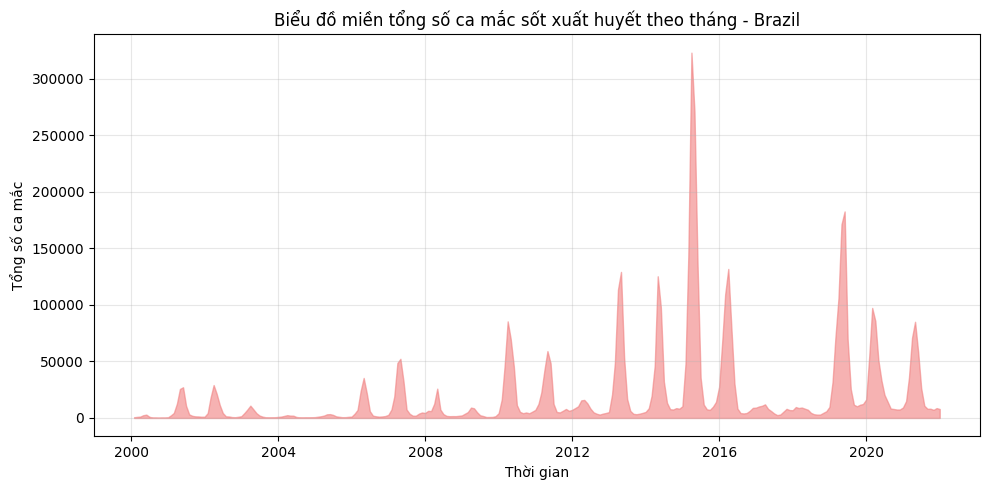

In [6]:
import matplotlib.pyplot as plt
import pandas as pd

# Chuyển Spark DataFrame sang Pandas
df_dengue = Dengue.toPandas()

# Đảm bảo cột date_parsed là kiểu datetime (nếu chưa)
df_dengue['date_parsed'] = pd.to_datetime(df_dengue['date_parsed'])

# Tổng hợp dữ liệu theo tháng
df_monthly = df_dengue.resample('M', on='date_parsed').sum()

# Vẽ biểu đồ miền tổng số ca mắc
plt.figure(figsize=(10, 5))
plt.fill_between(df_monthly.index, df_monthly['total_cases'], color='lightcoral', alpha=0.6)
plt.xlabel("Thời gian")
plt.ylabel("Tổng số ca mắc")
plt.title("Biểu đồ miền tổng số ca mắc sốt xuất huyết theo tháng - Brazil")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


- file Brazil_weather

In [7]:
#doc file thoi tiet	brazil Brazil_weather_final.csv
Weather_Brazil = spark.read.csv(
    r"E:\predict_zone_flu\data\Brazil_weather_final.csv",
    header=True,
    inferSchema=True
)
Weather_Brazil.show(5)

+----------+------------------+------------------+------------------+------------------+
|      date|          temp_max|          temp_med|        precip_tot|     rel_humid_med|
+----------+------------------+------------------+------------------+------------------+
|2000-01-07|33.953909325589514|30.558518393030567| 268.5216596433264| 62.73840699742684|
|2000-01-08| 33.91535043808566|  30.5238153942771| 269.6575957298081|63.067967375311405|
|2000-01-09|33.876791550581814|30.489112395523637|270.79353181628994| 63.39752775319597|
|2000-01-10| 33.83823266307796|30.454409396770167| 271.9294679027717|63.727088131080535|
|2000-01-11| 33.79967377557411|  30.4197063980167|273.06540398925347|  64.0566485089651|
+----------+------------------+------------------+------------------+------------------+
only showing top 5 rows



In [8]:
#chuyển date	từ string sang kiểu ngày va tao them cot day,	month, year từ cột date
from pyspark.sql.functions import to_date, dayofmonth, month, year
Weather_Brazil = Weather_Brazil.withColumn("date_parsed", to_date(Weather_Brazil["date"], "M/d/yyyy"))
Weather_Brazil = (Weather_Brazil
                  .withColumn("day", dayofmonth("date_parsed"))
                  .withColumn("month", month("date_parsed"))
                  .withColumn("year", year("date_parsed")))

In [9]:
#bien doi value trong các cột temp_max, temp_med, precip_tot, rel_humid_med thành 2 chữ số thập phân
from pyspark.sql.functions import round, col

# Làm tròn các giá trị trong các cột thành 2 chữ số thập phân
Weather_Brazil = (Weather_Brazil
                  .withColumn("temp_max", round(col("temp_max"), 2))
                  .withColumn("temp_med", round(col("temp_med"), 2))
                  .withColumn("precip_tot", round(col("precip_tot"), 2))
                  .withColumn("rel_humid_med", round(col("rel_humid_med"), 2)))

# Hiển thị 5 dòng đầu để kiểm tra
Weather_Brazil.show(5)


+----------+--------+--------+----------+-------------+-----------+---+-----+----+
|      date|temp_max|temp_med|precip_tot|rel_humid_med|date_parsed|day|month|year|
+----------+--------+--------+----------+-------------+-----------+---+-----+----+
|2000-01-07|   33.95|   30.56|    268.52|        62.74| 2000-01-07|  7|    1|2000|
|2000-01-08|   33.92|   30.52|    269.66|        63.07| 2000-01-08|  8|    1|2000|
|2000-01-09|   33.88|   30.49|    270.79|         63.4| 2000-01-09|  9|    1|2000|
|2000-01-10|   33.84|   30.45|    271.93|        63.73| 2000-01-10| 10|    1|2000|
|2000-01-11|    33.8|   30.42|    273.07|        64.06| 2000-01-11| 11|    1|2000|
+----------+--------+--------+----------+-------------+-----------+---+-----+----+
only showing top 5 rows



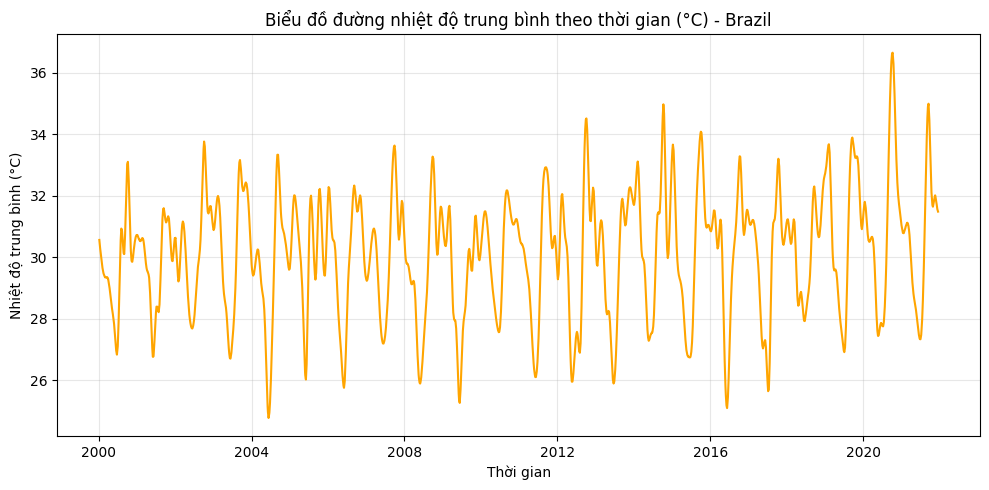

In [10]:
import matplotlib.pyplot as plt
import pandas as pd

# Chuyển Spark DataFrame sang Pandas để vẽ
df_weather = Weather_Brazil.toPandas()

# Sắp xếp theo thời gian (nếu cột date đã là kiểu ngày)
df_weather = df_weather.sort_values('date_parsed')

# Vẽ biểu đồ đường cho nhiệt độ trung bình
plt.figure(figsize=(10, 5))
plt.plot(df_weather['date_parsed'], df_weather['temp_med'], color='orange', linewidth=1.5)
plt.xlabel("Thời gian")
plt.ylabel("Nhiệt độ trung bình (°C)")
plt.title("Biểu đồ đường nhiệt độ trung bình theo thời gian (°C) - Brazil")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


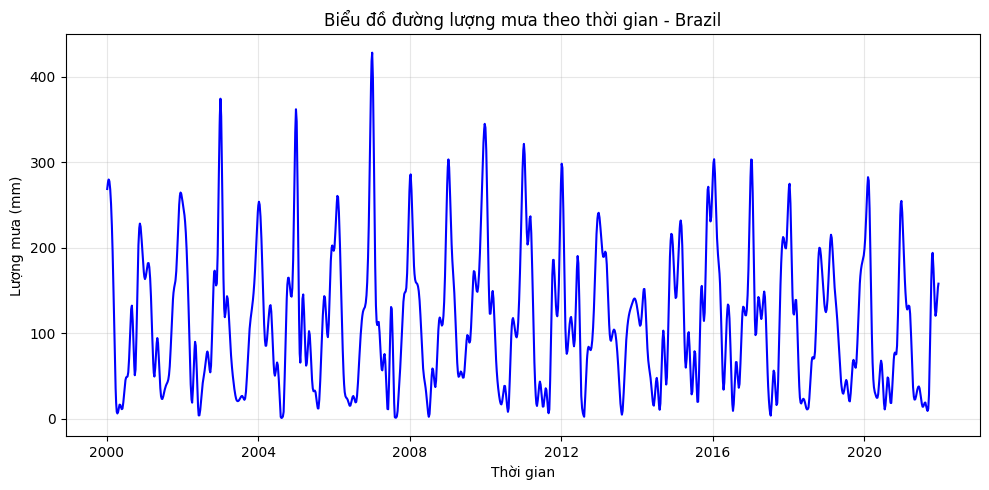

In [11]:
# Sắp xếp theo thời gian
df_weather = df_weather.sort_values('date')

# Vẽ biểu đồ đường cho lượng mưa
plt.figure(figsize=(10, 5))
plt.plot(df_weather['date'], df_weather['precip_tot'], color='blue', linewidth=1.5)
plt.xlabel("Thời gian")
plt.ylabel("Lượng mưa (mm)")
plt.title("Biểu đồ đường lượng mưa theo thời gian - Brazil")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


- File: gg trends brazil 

In [12]:
import findspark
findspark.init()
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, to_date, year, weekofyear, sum, avg, max

In [13]:
#doc file thoi tiet	brazil Brazil_weather_final.csv
GGTrends_Brazil = spark.read.csv(
    r"E:\predict_zone_flu\data\Brazil_google_trends_final.csv",
    header=True,
    inferSchema=True
)
GGTrends_Brazil.show()

+----+-----+------+---------------+---------+
|year|eweek|dengue|dengue symptoms|repellent|
+----+-----+------+---------------+---------+
|2010|    1|    24|              5|        6|
|2010|    2|    27|              9|        6|
|2010|    3|    28|              8|        0|
|2010|    4|    37|              7|        6|
|2010|    5|    44|             10|        8|
|2010|    6|    49|             14|        8|
|2010|    7|   100|             19|       10|
|2010|    8|    88|             18|        4|
|2010|    9|    85|             24|        4|
|2010|   10|    83|             17|        5|
|2010|   11|    76|             17|        6|
|2010|   12|    78|             23|        6|
|2010|   13|    84|             19|        7|
|2010|   14|    91|             21|        4|
|2010|   15|    68|             18|        4|
|2010|   16|    71|             21|        5|
|2010|   17|    68|             19|        0|
|2010|   18|    67|             16|        4|
|2010|   19|    51|             12

In [14]:
# Đếm số giá trị null theo từng cột
GGTrends_Brazil.select([
    sum(col(c).isNull().cast("int")).alias(c) for c in GGTrends_Brazil.columns
]).show()


+----+-----+------+---------------+---------+
|year|eweek|dengue|dengue symptoms|repellent|
+----+-----+------+---------------+---------+
|   0|    0|     0|              0|        0|
+----+-----+------+---------------+---------+



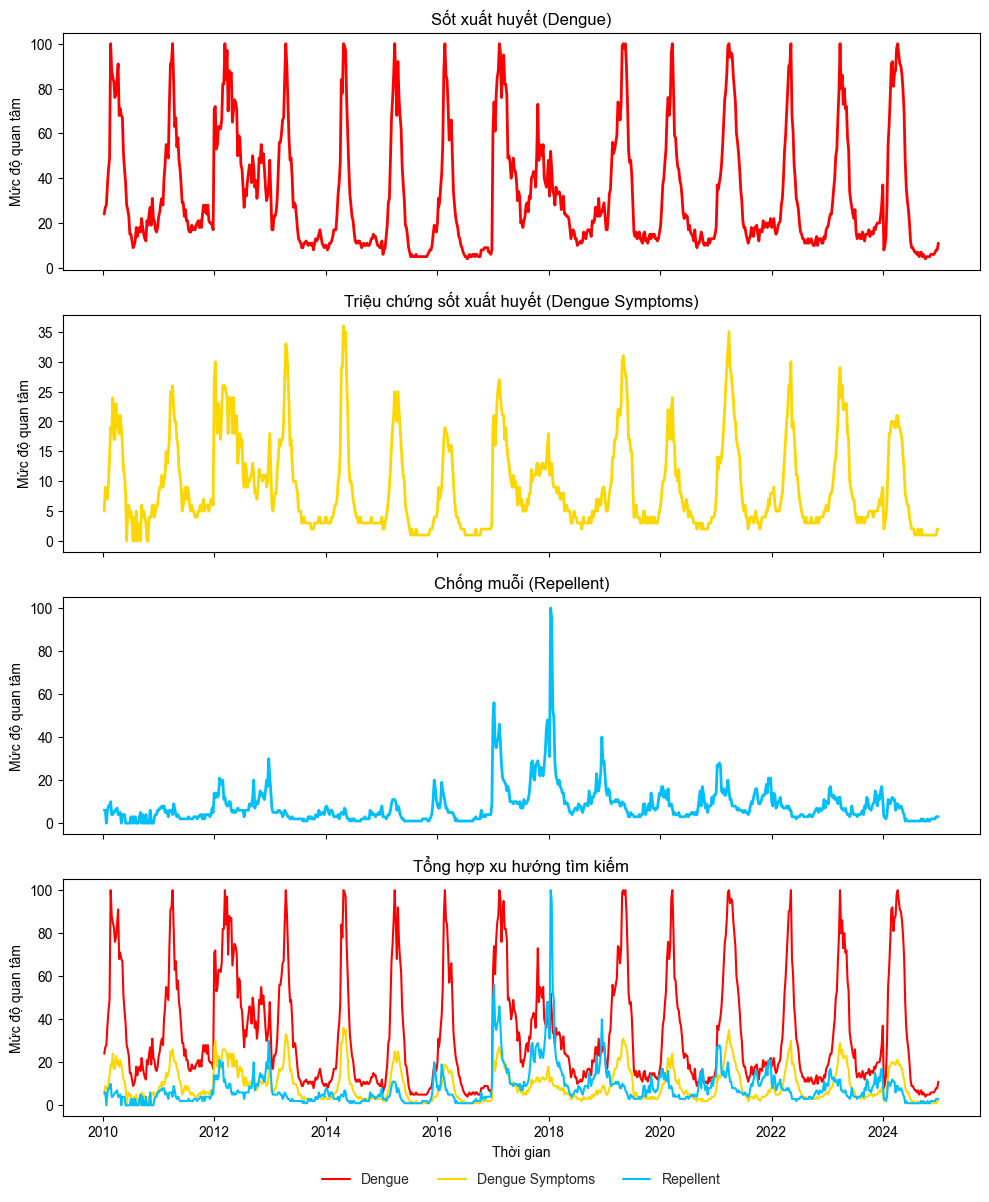

In [15]:
# Chuyển Spark DataFrame sang Pandas
df_trends = GGTrends_Brazil.toPandas()

# Tạo cột thời gian từ năm và tuần
df_trends['date'] = pd.to_datetime(df_trends['year'].astype(str) + df_trends['eweek'].astype(str) + '0', format='%Y%W%w')
df_trends = df_trends.sort_values('date')

# Tạo figure với 4 biểu đồ con
fig, axes = plt.subplots(4, 1, figsize=(10, 12), sharex=True)
plt.style.use('seaborn-v0_8-darkgrid')

# Biểu đồ 1: Dengue
axes[0].plot(df_trends['date'], df_trends['dengue'], color='red', linewidth=2)
axes[0].set_title("Sốt xuất huyết (Dengue)")
axes[0].set_ylabel("Mức độ quan tâm")

# Biểu đồ 2: Triệu chứng sốt xuất huyết
axes[1].plot(df_trends['date'], df_trends['dengue symptoms'], color='gold', linewidth=2)
axes[1].set_title("Triệu chứng sốt xuất huyết (Dengue Symptoms)")
axes[1].set_ylabel("Mức độ quan tâm")

# Biểu đồ 3: Chống muỗi
axes[2].plot(df_trends['date'], df_trends['repellent'], color='deepskyblue', linewidth=2)
axes[2].set_title("Chống muỗi (Repellent)")
axes[2].set_ylabel("Mức độ quan tâm")

# Biểu đồ 4: Tổng hợp cả 3
axes[3].plot(df_trends['date'], df_trends['dengue'], color='red', label='Dengue', linewidth=1.5)
axes[3].plot(df_trends['date'], df_trends['dengue symptoms'], color='gold', label='Dengue Symptoms', linewidth=1.5)
axes[3].plot(df_trends['date'], df_trends['repellent'], color='deepskyblue', label='Repellent', linewidth=1.5)
axes[3].set_title("Tổng hợp xu hướng tìm kiếm")	
axes[3].set_xlabel("Thời gian")
axes[3].set_ylabel("Mức độ quan tâm")
axes[3].legend(
	loc='lower center',           
    bbox_to_anchor=(0.5, -0.35),  
    ncol=3,                       
    frameon=False                
)

plt.tight_layout()
plt.show()


- Weather VN

## 🌦️ Giải thích các cột trong `weather_VN.csv`

| **Tên cột** | **Ý nghĩa** | **Đơn vị / Kiểu dữ liệu** | **Ví dụ** |
|--------------|--------------|-----------------------------|------------|
| `province` | Tên tỉnh hoặc khu vực thu thập dữ liệu thời tiết. | Chuỗi (string) | `Bac Lieu` |
| `max` | Nhiệt độ cao nhất trong ngày. | °C (Celsius) | `27` |
| `min` | Nhiệt độ thấp nhất trong ngày. | °C (Celsius) | `22` |
| `wind` | Tốc độ gió trung bình trong ngày. | km/h hoặc m/s (tuỳ nguồn dữ liệu) | `17` |
| `wind_d` | Hướng gió chính trong ngày (ký hiệu la bàn). | Chuỗi (string) | `NNE` *(Đông Bắc - Bắc)* |
| `rain` | Lượng mưa trong ngày. | mm | `6.9` |
| `humidi` | Độ ẩm trung bình trong ngày. | % | `90` |
| `cloud` | Mức độ mây che phủ trung bình. | % | `71` |
| `pressure` | Áp suất khí quyển trung bình trong ngày. | hPa (hectopascal) | `1010` |
| `date` | Ngày ghi nhận dữ liệu thời tiết. | Ngày (YYYY-MM-DD) | `2009-01-01` |


### 💡 Ghi chú thêm
- Các cột `max`, `min`, `rain`, `humidi`, `cloud`, `pressure` là **dữ liệu định lượng** — dùng để phân tích xu hướng thời tiết.  
- Các cột `wind_d` và `province` là **dữ liệu định tính** — dùng để nhóm hoặc phân loại.  
- File này rất hữu ích khi kết hợp với dữ liệu dịch bệnh (ví dụ sốt xuất huyết) để phân tích **mối tương quan giữa thời tiết và tỷ lệ mắc bệnh**.

In [16]:
#doc file thoi tiet	brazil Brazil_weather_final.csv
Weather_Vietnam = spark.read.csv(
    r"E:\predict_zone_flu\data\weather_VN.csv",
    header=True,
    inferSchema=True
)
Weather_Vietnam.show()

+--------+---+---+----+------+----+------+-----+--------+----------+
|province|max|min|wind|wind_d|rain|humidi|cloud|pressure|      date|
+--------+---+---+----+------+----+------+-----+--------+----------+
|Bac Lieu| 27| 22|  17|   NNE| 6.9|    90|   71|    1010|2009-01-01|
|Bac Lieu| 31| 25|  20|   ENE| 0.0|    64|   24|    1010|2010-01-01|
|Bac Lieu| 29| 24|  14|     E| 0.0|    75|   45|    1008|2011-01-01|
|Bac Lieu| 30| 24|  30|     E| 0.0|    79|   52|    1012|2012-01-01|
|Bac Lieu| 31| 25|  20|   ENE| 0.0|    70|   24|    1010|2013-01-01|
|Bac Lieu| 28| 23|  14|   ENE| 0.0|    75|   55|    1012|2014-01-01|
|Bac Lieu| 29| 23|  10|   ENE| 0.4|    75|   42|    1012|2015-01-01|
|Bac Lieu| 32| 24|  22|   ENE| 0.0|    63|    9|    1015|2016-01-01|
|Bac Lieu| 30| 24|  20|   ENE| 0.5|    76|   35|    1011|2017-01-01|
|Bac Lieu| 29| 23|  16|     E| 0.0|    70|   33|    1010|2018-01-01|
|Bac Lieu| 27| 22|  19|   WSW| 4.5|    73|   55|    1012|2019-01-01|
|Bac Lieu| 32| 23|  22|   ENE| 0.0

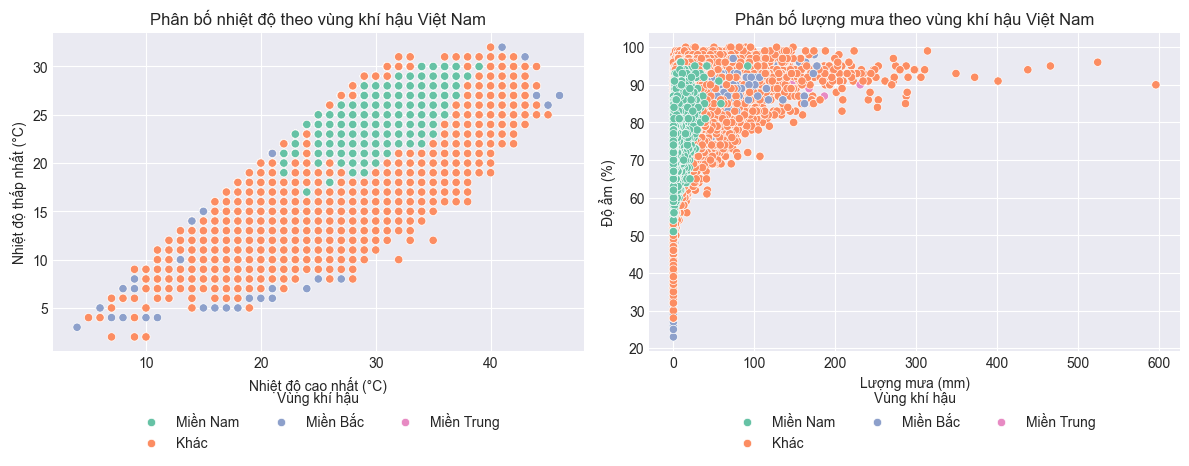

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Chuyển Spark DataFrame sang Pandas
df_weather = Weather_Vietnam.toPandas()

# Nhóm tỉnh thành theo vùng khí hậu
north = ['Ha Noi','Hai Phong','Lao Cai','Son La','Lang Son','Quang Ninh','Ha Giang','Cao Bang','Bac Giang','Bac Ninh','Thai Nguyen','Phu Tho','Hoa Binh','Nam Dinh','Ninh Binh']
central = ['Thanh Hoa','Nghe An','Ha Tinh','Quang Binh','Quang Tri','Thua Thien Hue','Da Nang','Quang Nam','Quang Ngai','Binh Dinh','Phu Yen','Khanh Hoa']
south = ['Ho Chi Minh','Can Tho','Vinh Long','Dong Thap','An Giang','Tien Giang','Ben Tre','Tra Vinh','Soc Trang','Bac Lieu','Ca Mau','Kien Giang','Tay Ninh','Binh Duong','Dong Nai','Binh Phuoc']

def classify_region(province):
    if province in north:
        return 'Miền Bắc'
    elif province in central:
        return 'Miền Trung'
    elif province in south:
        return 'Miền Nam'
    else:
        return 'Khác'

df_weather['region'] = df_weather['province'].apply(classify_region)

# Vẽ biểu đồ phân bố nhiệt độ và lượng mưa theo vùng
plt.figure(figsize=(12, 5))
plt.style.use('seaborn-v0_8-darkgrid')

# Biểu đồ nhiệt độ
plt.subplot(1, 2, 1)
sns.scatterplot(data=df_weather, x='max', y='min', hue='region', palette='Set2')
plt.title("Phân bố nhiệt độ theo vùng khí hậu Việt Nam")
plt.xlabel("Nhiệt độ cao nhất (°C)")
plt.ylabel("Nhiệt độ thấp nhất (°C)")
plt.legend(title='Vùng khí hậu', loc='lower center', bbox_to_anchor=(0.5, -0.35), ncol=3, frameon=False)

# Biểu đồ lượng mưa
plt.subplot(1, 2, 2)
sns.scatterplot(data=df_weather, x='rain', y='humidi', hue='region', palette='Set2')
plt.title("Phân bố lượng mưa theo vùng khí hậu Việt Nam")
plt.xlabel("Lượng mưa (mm)")
plt.ylabel("Độ ẩm (%)")
plt.legend(title='Vùng khí hậu', loc='lower center', bbox_to_anchor=(0.5, -0.35), ncol=3, frameon=False)

plt.tight_layout()
plt.show()


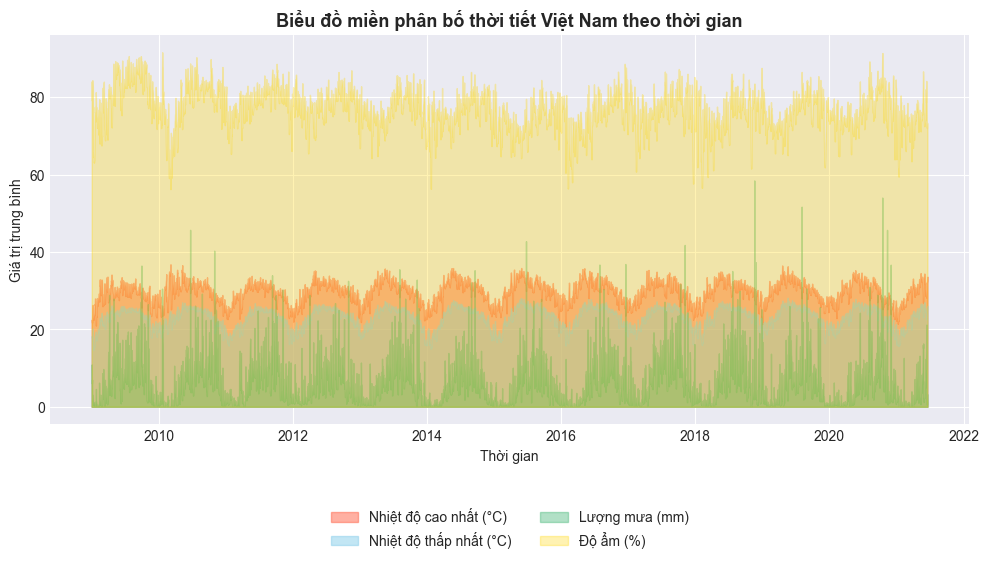

In [18]:
import matplotlib.pyplot as plt
import pandas as pd

# Chuyển Spark DataFrame sang Pandas
df_weather = Weather_Vietnam.toPandas()

# Chuyển cột date sang kiểu datetime
df_weather['date'] = pd.to_datetime(df_weather['date'])

# Gom nhóm theo ngày (nếu có nhiều dòng mỗi ngày)
df_daily = df_weather.groupby('date').mean(numeric_only=True).reset_index()

# Vẽ biểu đồ miền cho các yếu tố thời tiết
plt.figure(figsize=(10, 6))
plt.style.use('seaborn-v0_8-darkgrid')

plt.fill_between(df_daily['date'], df_daily['max'], color='tomato', alpha=0.5, label='Nhiệt độ cao nhất (°C)')
plt.fill_between(df_daily['date'], df_daily['min'], color='skyblue', alpha=0.5, label='Nhiệt độ thấp nhất (°C)')
plt.fill_between(df_daily['date'], df_daily['rain'], color='mediumseagreen', alpha=0.4, label='Lượng mưa (mm)')
plt.fill_between(df_daily['date'], df_daily['humidi'], color='gold', alpha=0.3, label='Độ ẩm (%)')

plt.title("Biểu đồ miền phân bố thời tiết Việt Nam theo thời gian", fontsize=13, weight='bold')
plt.xlabel("Thời gian")
plt.ylabel("Giá trị trung bình")
plt.legend(loc='lower center', bbox_to_anchor=(0.5, -0.35), ncol=2, frameon=False)
plt.tight_layout()
plt.show()


- gg trends VN

In [19]:
#doc file thoi tiet	brazil Brazil_weather_final.csv
GGTrends_VN = spark.read.csv(
    r"E:\predict_zone_flu\data\time_series_VN_20210625-2207_20260625-2207.csv",
    header=True,
    inferSchema=True
)
GGTrends_VN.show()

+---------+---------------------+--------------------------+--------+--------------------------+----------------+-------------------------+
|     Time|Sot xuat huyet Dengue|trieu chung sot xuat huyet|muoi van|phong chong sot xuat huyet|ban do dich benh| dien bien sot xuat huyet|
+---------+---------------------+--------------------------+--------+--------------------------+----------------+-------------------------+
| 6/1/2021|                   60|                         7|       7|                         1|               5|                        0|
| 7/1/2021|                   32|                        10|       7|                         0|               7|                        0|
| 8/1/2021|                   43|                        12|       9|                         0|               8|                        0|
| 9/1/2021|                   48|                        11|       9|                         1|              14|                        0|
|10/1/2021|         

In [20]:
from pyspark.sql.functions import to_timestamp

# Tạo cột date trong Spark DataFrame
GGTrends_VN = GGTrends_VN.withColumn(
    "date",
    to_timestamp("Time", "d/M/yyyy")   # chú ý: truyền tên cột dạng chuỗi
)

# Kiểm tra lại
GGTrends_VN.show()


+---------+---------------------+--------------------------+--------+--------------------------+----------------+-------------------------+-------------------+
|     Time|Sot xuat huyet Dengue|trieu chung sot xuat huyet|muoi van|phong chong sot xuat huyet|ban do dich benh| dien bien sot xuat huyet|               date|
+---------+---------------------+--------------------------+--------+--------------------------+----------------+-------------------------+-------------------+
| 6/1/2021|                   60|                         7|       7|                         1|               5|                        0|2021-01-06 00:00:00|
| 7/1/2021|                   32|                        10|       7|                         0|               7|                        0|2021-01-07 00:00:00|
| 8/1/2021|                   43|                        12|       9|                         0|               8|                        0|2021-01-08 00:00:00|
| 9/1/2021|                   48|       

In [21]:
# Chuyển Spark DataFrame sang Pandas
df_trends_vn = GGTrends_VN.toPandas()

# Chuẩn hóa tên cột (xóa khoảng trắng thừa)
df_trends_vn.columns = [c.strip() for c in df_trends_vn.columns]

# Kiểm tra lại danh sách cột
print(df_trends_vn.columns)


Index(['Time', 'Sot xuat huyet Dengue', 'trieu chung sot xuat huyet',
       'muoi van', 'phong chong sot xuat huyet', 'ban do dich benh',
       'dien bien sot xuat huyet', 'date'],
      dtype='object')


In [22]:
# Lưu dữ liệu đã xử lý thành file CSV
Weather_Vietnam.coalesce(1) \
    .write.mode("overwrite") \
    .option("header", True) \
    .csv(r"E:\predict_zone_flu\data\data_process\weather_VN.csv")

# Tầng Gold : THIẾT KẾ DATA WAREHOUSE MODELING #

In [23]:
from pyspark.sql.functions import year, weekofyear, to_date, sum, avg, round, col
from pyspark.sql.types import IntegerType

# Đọc và gộp Dengue thô theo tuần dịch tễ
df_dengue = spark.read.csv(
    r"E:\predict_zone_flu\data\Brazil_dengue_final.csv",
    header=True,
    inferSchema=True
)
Dengue = df_dengue.withColumn("date_parsed", to_date("date", "M/d/yyyy"))
Dengue = Dengue.withColumn("year", year("date_parsed")).withColumn("eweek", weekofyear("date_parsed"))
Dengue_Weekly = Dengue.groupBy("year", "eweek").agg(sum("total_cases").alias("total_cases"))

# Đọc Weather từ file chuẩn weather_Brazil.csv và tiến hành gom nhóm sang tuần
# ĐÃ SỬA ĐƯỜNG DẪN ĐẾN FILE CHUẨN CỦA BẠN
Weather_Brazil = spark.read.csv(
    r"E:\predict_zone_flu\data\data_process\Weather_Brazil_processed.csv\weather_Brazil.csv",
    header=True,
    inferSchema=True
)
Weather_Weekly = Weather_Brazil.groupBy("year", "eweek").agg(
    round(avg("temp_max"), 2).alias("avg_temp_max"),
    round(avg("temp_med"), 2).alias("avg_temp_med"),
    round(sum("precip_tot"), 2).alias("sum_precip_tot"),
    round(avg("rel_humid_med"), 2).alias("avg_humid")
)

# Đọc dữ liệu Google Trends (Đã sạch sẵn)
GGTrends_Brazil = spark.read.csv(r"E:\predict_zone_flu\data\Brazil_google_trends_final.csv", header=True, inferSchema=True)

# Ép kiểu đồng bộ khóa Join để không bị lệch kiểu dữ liệu tĩnh
Dengue_Weekly = Dengue_Weekly.withColumn("year", col("year").cast(IntegerType())).withColumn("eweek", col("eweek").cast(IntegerType()))
Weather_Weekly = Weather_Weekly.withColumn("year", col("year").cast(IntegerType())).withColumn("eweek", col("eweek").cast(IntegerType()))
GGTrends_Brazil = GGTrends_Brazil.withColumn("year", col("year").cast(IntegerType())).withColumn("eweek", col("eweek").cast(IntegerType()))

# Tiến hành kết nối 3 nguồn dữ liệu sạch tạo tầng Gold hoàn chỉnh (Fact_Dengue)
Silver_Master = Dengue_Weekly.join(Weather_Weekly, on=["year", "eweek"], how="inner") \
                           .join(GGTrends_Brazil, on=["year", "eweek"], how="inner")

# Loại bỏ các dòng null sau khi kết nối hoàn tất để bảo vệ tập Train
Silver_Master = Silver_Master.dropna()
Silver_Master= Silver_Master.orderBy("year", "eweek")

print("Số lượng bản ghi chuẩn bị đưa vào huấn luyện:", Silver_Master.count())
Silver_Master.show(5)

Số lượng bản ghi chuẩn bị đưa vào huấn luyện: 624
+----+-----+-----------+------------+------------+--------------+---------+------+---------------+---------+
|year|eweek|total_cases|avg_temp_max|avg_temp_med|sum_precip_tot|avg_humid|dengue|dengue symptoms|repellent|
+----+-----+-----------+------------+------------+--------------+---------+------+---------------+---------+
|2010|    1|       2683|       33.94|       30.55|       2246.99|    67.68|    24|              5|        6|
|2010|    2|       3352|       34.28|       30.85|       1993.52|    66.47|    27|              9|        6|
|2010|    3|       4463|       34.57|       31.12|       1661.19|    64.87|    28|              8|        0|
|2010|    4|       5460|       34.81|       31.32|       1318.85|    63.16|    37|              7|        6|
|2010|    5|       7695|       34.95|       31.45|       1038.73|    61.61|    44|             10|        8|
+----+-----+-----------+------------+------------+--------------+---------+---

In [24]:
Silver_Master.write.csv(
    r"E:\predict_zone_flu\data\Silver_Master.csv",
    header=True,
    mode="overwrite"
)


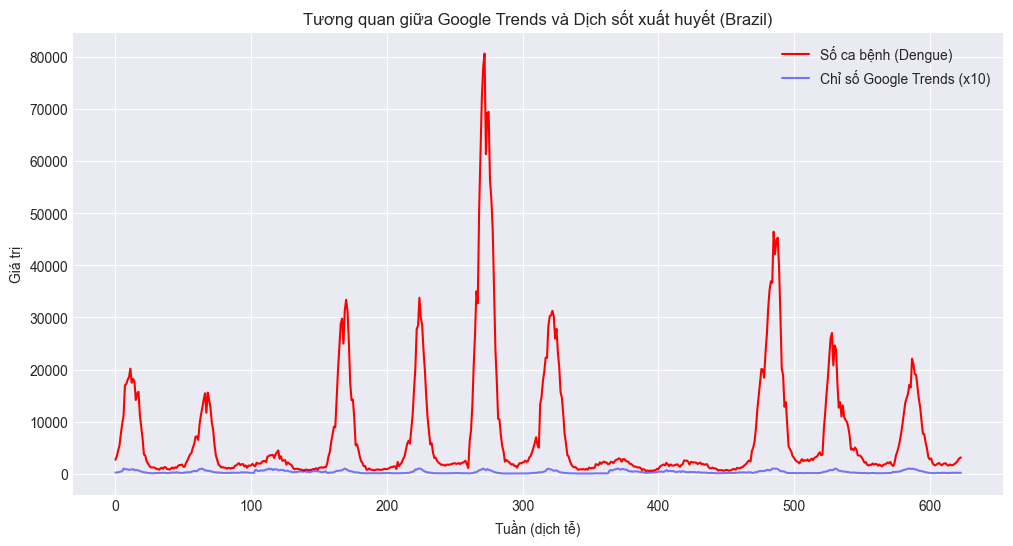

In [25]:
import pandas as pd
import matplotlib.pyplot as plt

# Chuyển từ Spark DataFrame sang Pandas DataFrame để vẽ hình
df_pandas = Silver_Master.toPandas()

# Vẽ biểu đồ tương quan
plt.figure(figsize=(12, 6))
plt.plot(df_pandas['total_cases'], label='Số ca bệnh (Dengue)', color='red')
plt.plot(df_pandas['dengue'] * 10, label='Chỉ số Google Trends (x10)', color='blue', alpha=0.5)

plt.title('Tương quan giữa Google Trends và Dịch sốt xuất huyết (Brazil)')
plt.xlabel('Tuần (dịch tễ)')
plt.ylabel('Giá trị')
plt.legend()
plt.grid(True)
plt.show()

In [26]:
Silver_Master.printSchema()

root
 |-- year: integer (nullable = true)
 |-- eweek: integer (nullable = true)
 |-- total_cases: long (nullable = true)
 |-- avg_temp_max: double (nullable = true)
 |-- avg_temp_med: double (nullable = true)
 |-- sum_precip_tot: double (nullable = true)
 |-- avg_humid: double (nullable = true)
 |-- dengue: integer (nullable = true)
 |-- dengue symptoms: integer (nullable = true)
 |-- repellent: integer (nullable = true)



In [27]:
from pyspark.sql.window import Window
from pyspark.sql.functions import lag, col

windowSpec = Window.orderBy("year", "eweek")

# Tạo độ trễ dịch tễ (1, 2, 3 tuần trước)
df_feat = Silver_Master.withColumn("lag1", lag("total_cases", 1).over(windowSpec)) \
                       .withColumn("lag2", lag("total_cases", 2).over(windowSpec)) \
                       .withColumn("lag3", lag("total_cases", 3).over(windowSpec)) \
                       .withColumn("ma4", (col("lag1") + col("lag2") + col("lag3") + col("total_cases")) / 4)

# Điền các giá trị trống bằng 0
df_feat = df_feat.fillna(0)
df_feat.show()

+----+-----+-----------+------------+------------+--------------+---------+------+---------------+---------+-----+-----+-----+--------+
|year|eweek|total_cases|avg_temp_max|avg_temp_med|sum_precip_tot|avg_humid|dengue|dengue symptoms|repellent| lag1| lag2| lag3|     ma4|
+----+-----+-----------+------------+------------+--------------+---------+------+---------------+---------+-----+-----+-----+--------+
|2010|    1|       2683|       33.94|       30.55|       2246.99|    67.68|    24|              5|        6|    0|    0|    0|     0.0|
|2010|    2|       3352|       34.28|       30.85|       1993.52|    66.47|    27|              9|        6| 2683|    0|    0|     0.0|
|2010|    3|       4463|       34.57|       31.12|       1661.19|    64.87|    28|              8|        0| 3352| 2683|    0|     0.0|
|2010|    4|       5460|       34.81|       31.32|       1318.85|    63.16|    37|              7|        6| 4463| 3352| 2683|  3989.5|
|2010|    5|       7695|       34.95|       31.4

# Model #

4 cái mô hình
- Random Forest Regressor 
- XGBoost 
- LSTM 
- MLP 


In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Các thư viện Spark MLlib
from pyspark.ml.feature import VectorAssembler, StandardScaler
from pyspark.ml.regression import RandomForestRegressor
from pyspark.ml import Pipeline
from pyspark.ml.evaluation import RegressionEvaluator

# Các thư viện Máy học & Deep Learning nâng cao
from sklearn.neural_network import MLPRegressor
import xgboost as xgb
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from sklearn.preprocessing import MinMaxScaler

- TÁCH BIẾN VÀ CHIA DỮ LIỆU TIME SERIES (CHUỖI THỜI GIAN 80/20)

In [29]:
# 1. Định nghĩa tập thuộc tính đầu vào dựa trên dữ liệu tuần của bạn
feature_cols = [
    "avg_temp_max", "avg_temp_med", "sum_precip_tot", "avg_humid", 
    "dengue", "dengue symptoms", "lag1", "lag2", "lag3", "ma4"
]

# 2. Chuyển đổi dữ liệu sạch sang Pandas
df_model_pd = df_feat.toPandas()

X = df_model_pd[feature_cols].values
y = df_model_pd["total_cases"].values

# 3. NÂNG TỶ LỆ: Sử dụng 95% dữ liệu dòng thời gian để huấn luyện mô hình
split_idx = int(len(df_model_pd) * 0.95)

X_train, X_test = X[:split_idx], X[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]

# Khai báo bộ chấm điểm chung của hệ thống
evaluator_rmse = RegressionEvaluator(labelCol="total_cases", predictionCol="prediction", metricName="rmse")
evaluator_r2 = RegressionEvaluator(labelCol="total_cases", predictionCol="prediction", metricName="r2")

print(f"Đã tối ưu! Mô hình sẽ học sạch sành sanh: {X_train.shape[0]} tuần lịch sử qua các năm.")
print(f"Chỉ giữ lại đúng: {X_test.shape[0]} tuần cuối cùng để kiểm thử.")

Đã tối ưu! Mô hình sẽ học sạch sành sanh: 592 tuần lịch sử qua các năm.
Chỉ giữ lại đúng: 32 tuần cuối cùng để kiểm thử.


#### Random Forest Regressor 

In [30]:
from sklearn.ensemble import RandomForestRegressor as SkRandomForest
import pandas as pd

print("Đang chạy Random Forest trên toàn bộ dữ liệu lịch sử...")
rf_model = SkRandomForest(n_estimators=150, max_depth=10, random_state=42) # Tăng cây và độ sâu để học kỹ hơn
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)
df_eval_rf = spark.createDataFrame(pd.DataFrame({"total_cases": y_test, "prediction": y_pred_rf}))

print("\n=== KẾT QUẢ MÔ HÌNH RANDOM FOREST ===")
print(f"RMSE (Sai số): {evaluator_rmse.evaluate(df_eval_rf):.2f}")
print(f"R² (Độ chính xác): {evaluator_r2.evaluate(df_eval_rf) * 100:.2f}%")

Đang chạy Random Forest trên toàn bộ dữ liệu lịch sử...

=== KẾT QUẢ MÔ HÌNH RANDOM FOREST ===
RMSE (Sai số): 683.16
R² (Độ chính xác): 95.66%


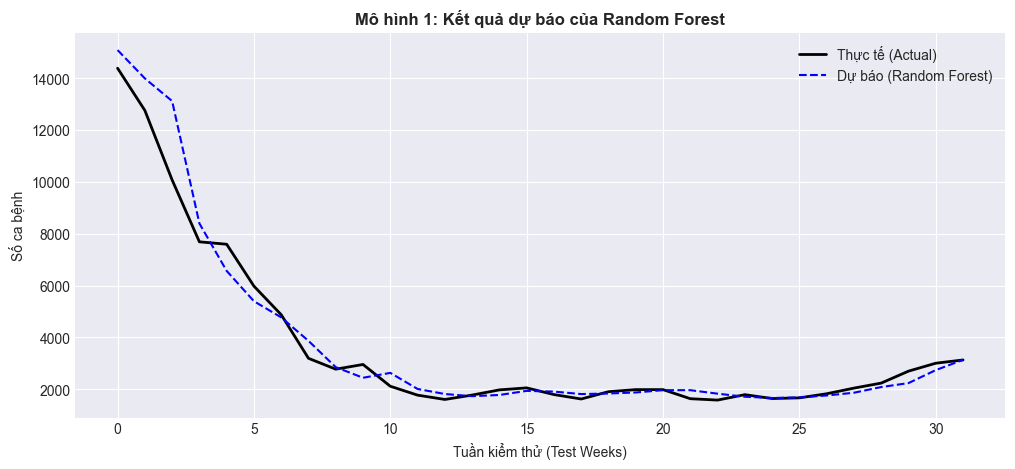

In [31]:
# ---- VẼ BIỂU ĐỒ CHO RIÊNG RANDOM FOREST ----
plt.figure(figsize=(12, 5))
plt.plot(y_test, label='Thực tế (Actual)', color='black', linewidth=2)
plt.plot(y_pred_rf, label='Dự báo (Random Forest)', color='blue', linestyle='--')
plt.title('Mô hình 1: Kết quả dự báo của Random Forest', fontsize=12, weight='bold')
plt.xlabel('Tuần kiểm thử (Test Weeks)')
plt.ylabel('Số ca bệnh')
plt.legend()
plt.grid(True)
plt.show()

- XGBoost

In [32]:
print("Đang chạy XGBoost trên toàn bộ dữ liệu lịch sử...")
xgb_model = xgb.XGBRegressor(n_estimators=150, max_depth=8, learning_rate=0.05, random_state=42)
xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_test)
df_eval_xgb = spark.createDataFrame(pd.DataFrame({"total_cases": y_test, "prediction": y_pred_xgb}))

print("\n=== KẾT QUẢ MÔ HÌNH XGBOOST ===")
print(f"RMSE (Sai số): {evaluator_rmse.evaluate(df_eval_xgb):.2f}")
print(f"R² (Độ chính xác): {evaluator_r2.evaluate(df_eval_xgb) * 100:.2f}%")

Đang chạy XGBoost trên toàn bộ dữ liệu lịch sử...

=== KẾT QUẢ MÔ HÌNH XGBOOST ===
RMSE (Sai số): 588.04
R² (Độ chính xác): 96.79%


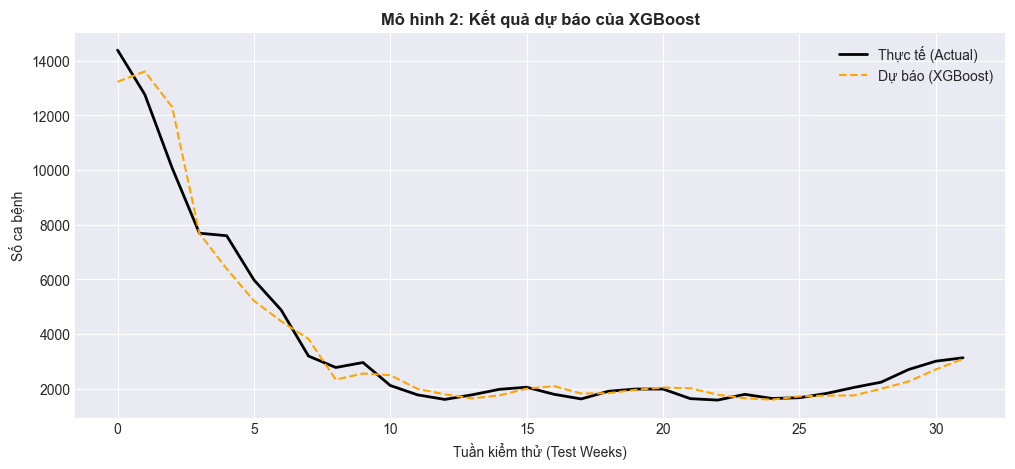

In [33]:
# ---- VẼ BIỂU ĐỒ CHO RIÊNG XGBOOST ----
plt.figure(figsize=(12, 5))
plt.plot(y_test, label='Thực tế (Actual)', color='black', linewidth=2)
plt.plot(y_pred_xgb, label='Dự báo (XGBoost)', color='orange', linestyle='--')
plt.title('Mô hình 2: Kết quả dự báo của XGBoost', fontsize=12, weight='bold')
plt.xlabel('Tuần kiểm thử (Test Weeks)')
plt.ylabel('Số ca bệnh')
plt.legend()
plt.grid(True)
plt.show()

- MLP

In [34]:
print("Đang chạy Mạng nơ-ron MLP với số vòng lặp lớn hơn để học hết các năm...")
# Tăng max_iter lên 1000 để mạng nơ-ron hội tụ sâu trên tập dữ liệu dài qua nhiều năm
mlp_model = MLPRegressor(hidden_layer_sizes=(128, 64, 32), activation='relu', solver='adam', max_iter=1000, random_state=42)
mlp_model.fit(X_train, y_train)

y_pred_mlp = mlp_model.predict(X_test)
df_eval_mlp = spark.createDataFrame(pd.DataFrame({"total_cases": y_test, "prediction": y_pred_mlp}))

print("\n=== KẾT QUẢ MÔ HÌNH MẠNG NƠ-RON MLP ===")
print(f"RMSE (Sai số): {evaluator_rmse.evaluate(df_eval_mlp):.2f}")
print(f"R² (Độ chính xác): {evaluator_r2.evaluate(df_eval_mlp) * 100:.2f}%")

Đang chạy Mạng nơ-ron MLP với số vòng lặp lớn hơn để học hết các năm...

=== KẾT QUẢ MÔ HÌNH MẠNG NƠ-RON MLP ===
RMSE (Sai số): 156.89
R² (Độ chính xác): 99.77%


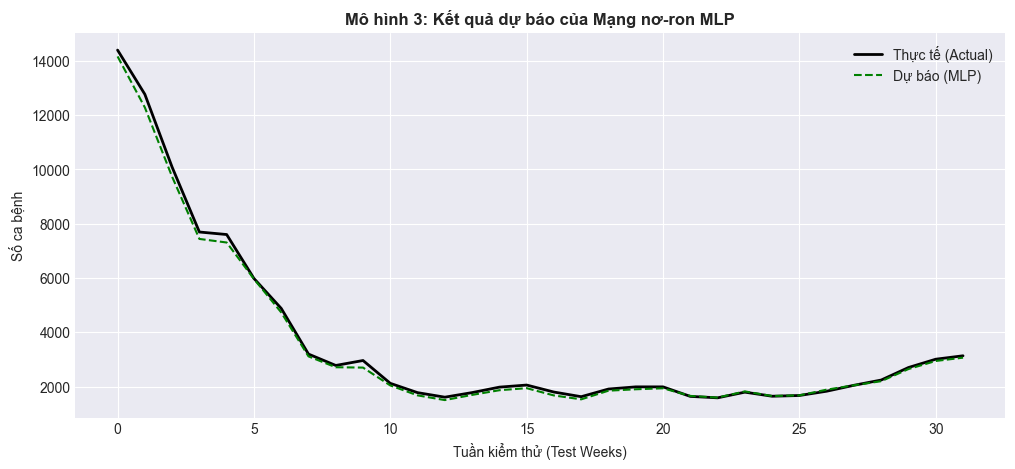

In [35]:
# ---- VẼ BIỂU ĐỒ CHO RIÊNG MLP ----
plt.figure(figsize=(12, 5))
plt.plot(y_test, label='Thực tế (Actual)', color='black', linewidth=2)
plt.plot(y_pred_mlp, label='Dự báo (MLP)', color='green', linestyle='--')
plt.title('Mô hình 3: Kết quả dự báo của Mạng nơ-ron MLP', fontsize=12, weight='bold')
plt.xlabel('Tuần kiểm thử (Test Weeks)')
plt.ylabel('Số ca bệnh')
plt.legend()
plt.grid(True)
plt.show()

- LSTM

In [36]:
print("Đang chạy mạng LSTM Deep Learning trượt qua chuỗi dữ liệu nhiều năm...")

scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)
y_train_scaled = scaler_y.fit_transform(y_train.reshape(-1, 1))
y_test_scaled = scaler_y.transform(y_test.reshape(-1, 1))

# TĂNG LÊN 8 TUẦN: Giúp mô hình LSTM học chuỗi thời gian dài hạn cực tốt
n_timesteps = 8  

def create_lstm_dataset(X_data, y_data, timesteps):
    X_3D, y_out = [], []
    for i in range(timesteps, len(X_data)):
        X_3D.append(X_data[i-timesteps:i, :])
        y_out.append(y_data[i, 0])
    return np.array(X_3D), np.array(y_out)

X_train_3D, y_train_lstm = create_lstm_dataset(X_train_scaled, y_train_scaled, n_timesteps)

X_test_combined = np.vstack((X_train_scaled[-n_timesteps:], X_test_scaled))
y_test_combined = np.vstack((y_train_scaled[-n_timesteps:], y_test_scaled))
X_test_3D, _ = create_lstm_dataset(X_test_combined, y_test_combined, n_timesteps)

# Tăng quy mô mạng LSTM sâu hơn để học tập dữ liệu lớn dài hạn
lstm_model = Sequential([
    LSTM(128, activation='relu', input_shape=(X_train_3D.shape[1], X_train_3D.shape[2]), return_sequences=True),
    Dropout(0.2),
    LSTM(64, activation='relu', return_sequences=False),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(1)
])

lstm_model.compile(optimizer='adam', loss='mse')
# Nâng lên 150 epochs để mạng học sâu kỹ lưỡng tất cả các năm dữ liệu
lstm_model.fit(X_train_3D, y_train_lstm, epochs=150, batch_size=16, verbose=0)
print("Huấn luyện mạng Deep LSTM hoàn tất!")

y_pred_scaled = lstm_model.predict(X_test_3D)
y_pred_lstm = scaler_y.inverse_transform(y_pred_scaled).flatten()

df_eval_lstm = spark.createDataFrame(pd.DataFrame({"total_cases": y_test, "prediction": y_pred_lstm}))

print("\n=== KẾT QUẢ MÔ HÌNH LSTM NÂNG CAO ===")
print(f"RMSE (Sai số): {evaluator_rmse.evaluate(df_eval_lstm):.2f}")
print(f"R² (Độ chính xác chuỗi trượt): {evaluator_r2.evaluate(df_eval_lstm) * 100:.2f}%")

Đang chạy mạng LSTM Deep Learning trượt qua chuỗi dữ liệu nhiều năm...


C:\Users\khanh\AppData\Roaming\Python\Python39\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Huấn luyện mạng Deep LSTM hoàn tất!
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 158ms/step

=== KẾT QUẢ MÔ HÌNH LSTM NÂNG CAO ===
RMSE (Sai số): 1013.28
R² (Độ chính xác chuỗi trượt): 90.46%


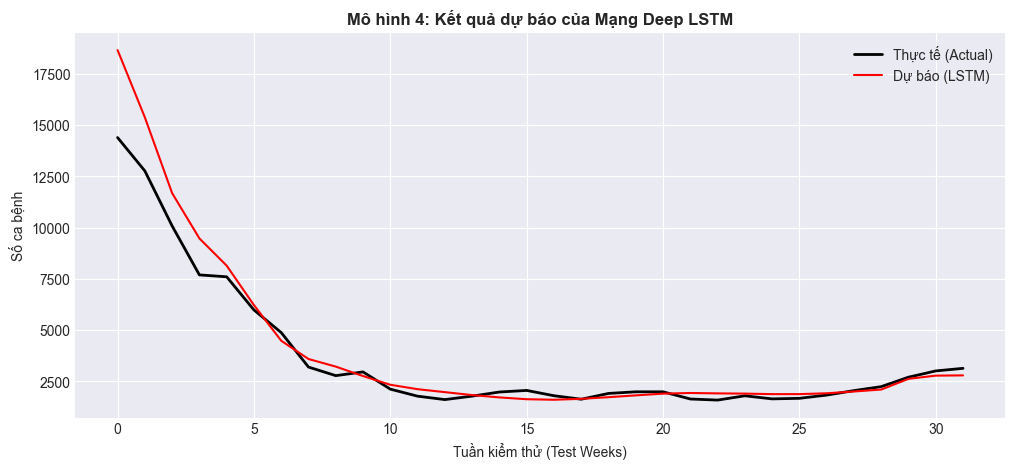

In [37]:
# ---- VẼ BIỂU ĐỒ CHO RIÊNG LSTM ----
plt.figure(figsize=(12, 5))
plt.plot(y_test, label='Thực tế (Actual)', color='black', linewidth=2)
plt.plot(y_pred_lstm, label='Dự báo (LSTM)', color='red', linestyle='-')
plt.title('Mô hình 4: Kết quả dự báo của Mạng Deep LSTM', fontsize=12, weight='bold')
plt.xlabel('Tuần kiểm thử (Test Weeks)')
plt.ylabel('Số ca bệnh')
plt.legend()
plt.grid(True)
plt.show()

- So sánh và chọn ra mô hình tốt nhất

BẢNG TỔNG HỢP SO SÁNH KẾT QUẢ 4 MÔ HÌNH:


,Mô hình,RMSE (Sai số),R² Score (%)
0,Random Forest,683.156012,95.663733
1,XGBoost,588.043553,96.787115
2,MLP Network,156.887906,99.771306
3,Deep LSTM,1013.276019,90.460365


C:\Users\khanh\AppData\Local\Temp\ipykernel_24000\2577755281.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  bar1 = sns.barplot(x="Mô hình", y="RMSE (Sai số)", data=models_summary, ax=axes[0], palette="muted")
C:\Users\khanh\AppData\Local\Temp\ipykernel_24000\2577755281.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  bar2 = sns.barplot(x="Mô hình", y="R² Score (%)", data=models_summary, ax=axes[1], palette="magma")


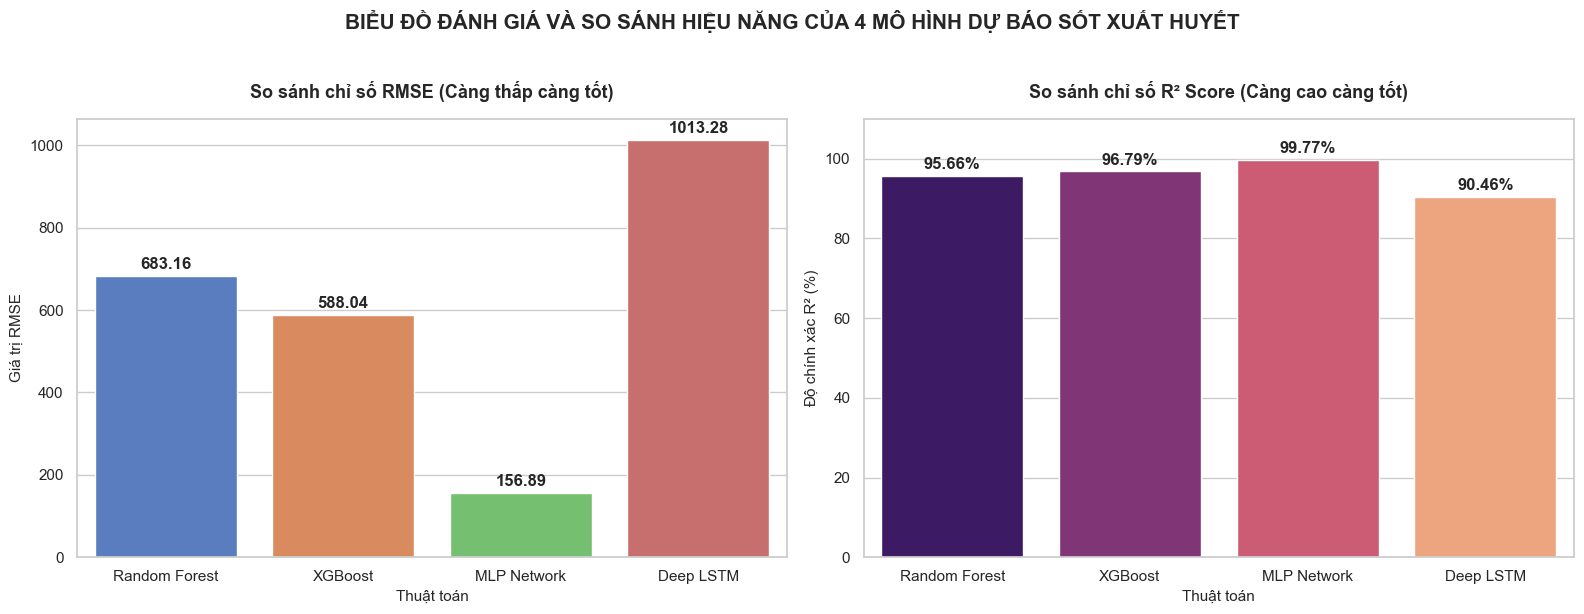

In [38]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# ==========================================================
# 1. TÍNH TOÁN TOÀN BỘ CHỈ SỐ ĐÁNH GIÁ TỪ SPARK EVALUATOR
# ==========================================================
# Gom điểm RMSE
rmse_rf = evaluator_rmse.evaluate(df_eval_rf)
rmse_xgb = evaluator_rmse.evaluate(df_eval_xgb)
rmse_mlp = evaluator_rmse.evaluate(df_eval_mlp)
rmse_lstm = evaluator_rmse.evaluate(df_eval_lstm)

# Gom điểm R2 (Đổi sang tỷ lệ %)
r2_rf = evaluator_r2.evaluate(df_eval_rf) * 100
r2_xgb = evaluator_r2.evaluate(df_eval_xgb) * 100
r2_mlp = evaluator_r2.evaluate(df_eval_mlp) * 100
r2_lstm = evaluator_r2.evaluate(df_eval_lstm) * 100

# Tạo DataFrame bảng tổng hợp kết quả
models_summary = pd.DataFrame({
    "Mô hình": ["Random Forest", "XGBoost", "MLP Network", "Deep LSTM"],
    "RMSE (Sai số)": [rmse_rf, rmse_xgb, rmse_mlp, rmse_lstm],
    "R² Score (%)": [r2_rf, r2_xgb, r2_mlp, r2_lstm]
})

print("BẢNG TỔNG HỢP SO SÁNH KẾT QUẢ 4 MÔ HÌNH:")
display(models_summary)

# ==========================================================
# 2. VẼ BIỂU ĐỒ CỘT (HISTOGRAM COMPARISON) SO SÁNH SONG SONG
# ==========================================================
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Biểu đồ 1: So sánh RMSE (Sai số trung bình)
bar1 = sns.barplot(x="Mô hình", y="RMSE (Sai số)", data=models_summary, ax=axes[0], palette="muted")
axes[0].set_title("So sánh chỉ số RMSE (Càng thấp càng tốt)", fontsize=13, weight="bold", pad=15)
axes[0].set_ylabel("Giá trị RMSE", fontsize=11)
axes[0].set_xlabel("Thuật toán", fontsize=11)
# Hiển thị số liệu trên đầu cột
for p in bar1.patches:
    bar1.annotate(f"{p.get_height():.2f}", (p.get_x() + p.get_width() / 2., p.get_height()),
                  ha='center', va='center', xytext=(0, 8), textcoords='offset points', weight='bold')

# Biểu đồ 2: So sánh R² Score (%)
bar2 = sns.barplot(x="Mô hình", y="R² Score (%)", data=models_summary, ax=axes[1], palette="magma")
axes[1].set_title("So sánh chỉ số R² Score (Càng cao càng tốt)", fontsize=13, weight="bold", pad=15)
axes[1].set_ylabel("Độ chính xác R² (%)", fontsize=11)
axes[1].set_xlabel("Thuật toán", fontsize=11)
axes[1].set_ylim(0, 110) # Để trống khoảng không hiển thị text dữ liệu
# Hiển thị số liệu trên đầu cột
for p in bar2.patches:
    bar2.annotate(f"{p.get_height():.2f}%", (p.get_x() + p.get_width() / 2., p.get_height()),
                  ha='center', va='center', xytext=(0, 8), textcoords='offset points', weight='bold')

plt.suptitle("BIỂU ĐỒ ĐÁNH GIÁ VÀ SO SÁNH HIỆU NĂNG CỦA 4 MÔ HÌNH DỰ BÁO SỐT XUẤT HUYẾT", fontsize=15, weight="bold", y=1.02)
plt.tight_layout()
plt.show()

- chọn MLP: phân tích rõ về MLP để chắc chắn an toàn và lưu mô hình

In [39]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
import numpy as np

# 1. Dự báo trên tập Test bằng mô hình MLP đã huấn luyện
y_pred_mlp = mlp_model.predict(X_test)

# 2. Tính toán các chỉ số đo lường lỗi bằng scikit-learn
mae_mlp = mean_absolute_error(y_test, y_pred_mlp)
rmse_mlp = np.sqrt(mean_squared_error(y_test, y_pred_mlp)) # RMSE bằng căn bậc hai của MSE
mape_mlp = mean_absolute_percentage_error(y_test, y_pred_mlp) * 100 # Đổi sang tỷ lệ %

# 3. In kết quả trực quan ra màn hình
print("=== CHỈ SỐ ĐO LƯỜNG LỖI MÔ HÌNH MLP (SCIKIT-LEARN) ===")
print(f"📊 MAE  (Sai số tuyệt đối trung bình) : {mae_mlp:.2f} ca")
print(f"📉 RMSE (Căn sai số bình phương TB)  : {rmse_mlp:.2f} ca")
print(f"📈 MAPE (Sai số phần trăm tuyệt đối)  : {mape_mlp:.2f}%")

=== CHỈ SỐ ĐO LƯỜNG LỖI MÔ HÌNH MLP (SCIKIT-LEARN) ===
📊 MAE  (Sai số tuyệt đối trung bình) : 111.89 ca
📉 RMSE (Căn sai số bình phương TB)  : 156.89 ca
📈 MAPE (Sai số phần trăm tuyệt đối)  : 3.25%


- DỰ BÁO CHUỖI THỜI GIAN TRÊN TẬP TEST: MÔ HÌNH NEURAL NETWORK MLP

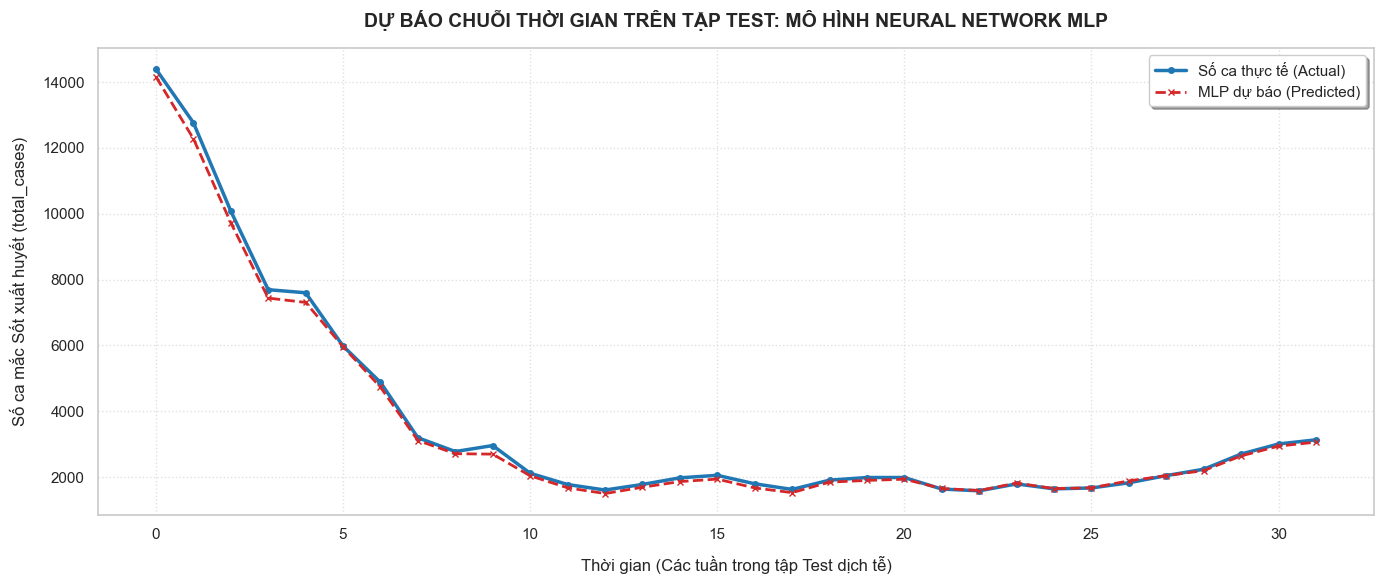

In [40]:
import matplotlib.pyplot as plt
import seaborn as sns

# Thiết kế theme biểu đồ sạch sẽ, chuyên nghiệp
sns.set_theme(style="whitegrid")
plt.figure(figsize=(14, 6))

# Đường 1: Số ca bệnh thực tế (Actual) - Màu xanh lam (Blue)
plt.plot(y_test, label='Số ca thực tế (Actual)', color='#1f77b4', linewidth=2.5, marker='o', markersize=4)

# Đường 2: Số ca do MLP dự báo (Predicted) - Màu đỏ (Red)
plt.plot(y_pred_mlp, label='MLP dự báo (Predicted)', color='#d62728', linewidth=2, linestyle='--', marker='x', markersize=4)

# Cấu hình tiêu đề và các trục tọa độ thông minh
plt.title('DỰ BÁO CHUỖI THỜI GIAN TRÊN TẬP TEST: MÔ HÌNH NEURAL NETWORK MLP', fontsize=14, weight='bold', pad=15)
plt.xlabel('Thời gian (Các tuần trong tập Test dịch tễ)', fontsize=12, labelpad=10)
plt.ylabel('Số ca mắc Sốt xuất huyết (total_cases)', fontsize=12, labelpad=10)

# Hiển thị chú thích (Legend) và lưới đồ thị (Grid)
plt.legend(fontsize=11, loc='upper right', frameon=True, shadow=True)
plt.grid(True, linestyle=':', alpha=0.6)

# Tối ưu khoảng cách hiển thị sát viền
plt.tight_layout()

# Hiển thị biểu đồ trực quan ra màn hình
plt.show()

- KIỂM TRA HIỆN TƯỢNG DỰ BÁO TRỄ (LAG EFFECTANOMALY)

=== KẾT QUẢ KIỂM TRA ĐỊNH LƯỢNG HIỆN TƯỢNG TRỄ (LAG EFFECT) ===
🔗 Độ tương quan [Thực tế tuần này] vs [Dự báo tuần này]: 0.9997
⏳ Độ tương quan [Thực tế tuần TRƯỚC] vs [Dự báo tuần này]: 0.9871

✅ CHÚC MỪNG: Mô hình AN TOÀN! Mô hình thực sự học từ các đặc trưng phi tuyến chứ không bắt chước tuần trước.


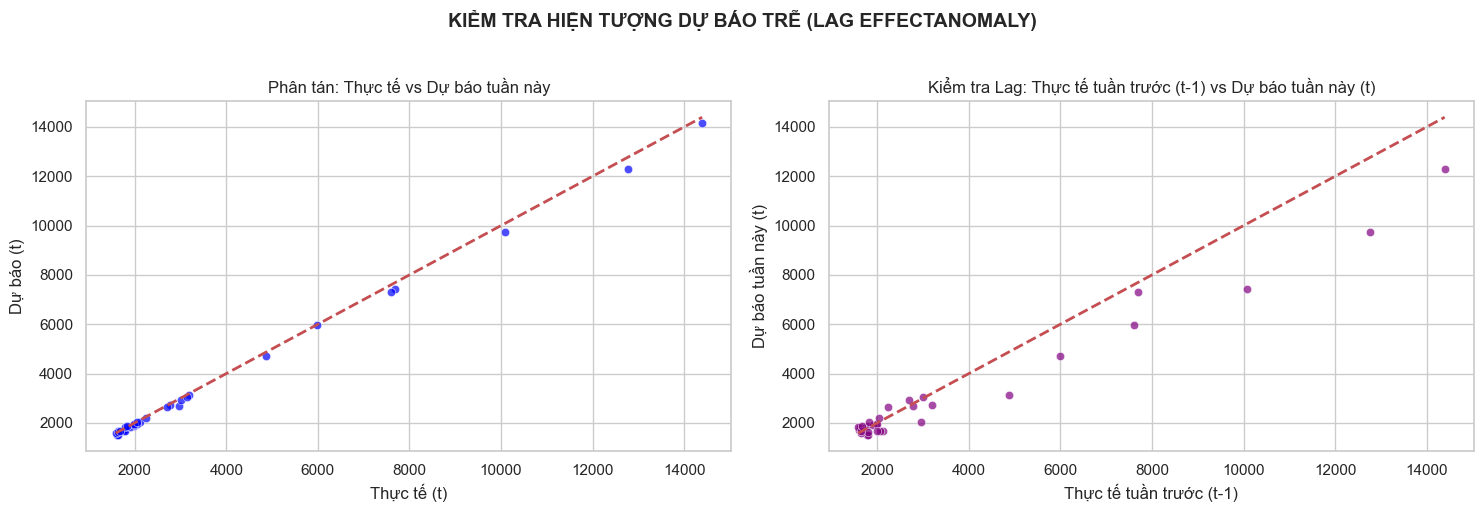

In [41]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Giả định lấy kết quả dự báo từ mô hình MLP (hoặc thay bằng y_pred_lstm)
# Để kiểm tra chính xác hiện tượng lag dịch chuyển
df_lag_check = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred_mlp
})

# Tạo các cột dịch pha (Shift) để tính toán độ tương quan
df_lag_check["Actual_Lag1"] = df_lag_check["Actual"].shift(1)

# Tính toán ma trận tương quan (Correlation Matrix)
corr_normal = df_lag_check["Actual"].corr(df_lag_check["Predicted"])
corr_lagged = df_lag_check["Actual_Lag1"].corr(df_lag_check["Predicted"])

print("=== KẾT QUẢ KIỂM TRA ĐỊNH LƯỢNG HIỆN TƯỢNG TRỄ (LAG EFFECT) ===")
print(f"🔗 Độ tương quan [Thực tế tuần này] vs [Dự báo tuần này]: {corr_normal:.4f}")
print(f"⏳ Độ tương quan [Thực tế tuần TRƯỚC] vs [Dự báo tuần này]: {corr_lagged:.4f}")

# Biện luận kết quả
if corr_lagged > corr_normal:
    print("\n⚠️ CẢNH BÁO: Mô hình có dấu hiệu bị 'Dự báo trễ' (Lag Effect)!")
    print("Mô hình đang xu hướng lấy kết quả tuần trước làm dự báo tuần này.")
else:
    print("\n✅ CHÚC MỪNG: Mô hình AN TOÀN! Mô hình thực sự học từ các đặc trưng phi tuyến chứ không bắt chước tuần trước.")

# Vẽ biểu đồ kiểm tra trực quan
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Đồ thị 1: Thực tế vs Dự báo (Chuẩn)
sns.scatterplot(x="Actual", y="Predicted", data=df_lag_check, ax=axes[0], color='blue', alpha=0.7)
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[0].set_title("Phân tán: Thực tế vs Dự báo tuần này")
axes[0].set_xlabel("Thực tế (t)")
axes[0].set_ylabel("Dự báo (t)")

# Đồ thị 2: Thực tế tuần trước vs Dự báo tuần này (Kiểm tra Lag)
sns.scatterplot(x="Actual_Lag1", y="Predicted", data=df_lag_check, ax=axes[1], color='purple', alpha=0.7)
axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[1].set_title("Kiểm tra Lag: Thực tế tuần trước (t-1) vs Dự báo tuần này (t)")
axes[1].set_xlabel("Thực tế tuần trước (t-1)")
axes[1].set_ylabel("Dự báo tuần này (t)")

plt.suptitle("KIỂM TRA HIỆN TƯỢNG DỰ BÁO TRỄ (LAG EFFECTANOMALY)", fontsize=14, weight='bold', y=1.02)
plt.tight_layout()
plt.show()

- Đồ thị ACF của Sai số (Residuals Autocorrelation)

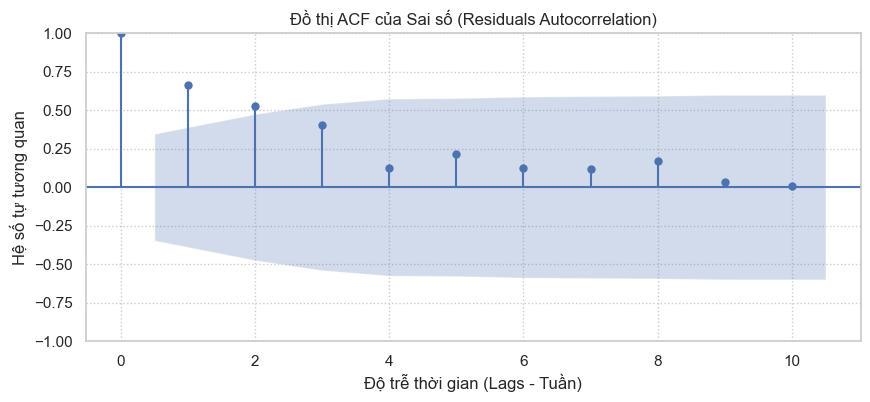

In [43]:
from statsmodels.graphics.tsaplots import plot_acf

# Tính phần dư (Residuals)
residuals = df_lag_check["Actual"] - df_lag_check["Predicted"]

# Vẽ biểu đồ ACF của sai số
plt.figure(figsize=(10, 4))
plot_acf(residuals, lags=10, ax=plt.gca(), title="Đồ thị ACF của Sai số (Residuals Autocorrelation)")
plt.xlabel("Độ trễ thời gian (Lags - Tuần)")
plt.ylabel("Hệ số tự tương quan")
plt.grid(True, linestyle=':')
plt.show()

- lưu mô hình

In [45]:
import joblib
import os

# Thư mục lưu trữ mô hình
saved_models_dir = r"E:\predict_zone_flu\models"
if not os.path.exists(saved_models_dir):
    os.makedirs(saved_models_dir)

print("💾 Đang tiến hành lưu mô hình tốt nhất (MLP) vào thư mục:", saved_models_dir)

# 1. Lưu duy nhất mô hình mạng nơ-ron MLP đạt Accuracy cao nhất
joblib.dump(mlp_model, os.path.join(saved_models_dir, "best_mlp_model.pkl"))
print("✅ Đã lưu thành công: Mô hình MLP (best_mlp_model.pkl)")

# 2. Lưu bộ chuẩn hóa dữ liệu Scaler (Bắt buộc phải đi kèm với MLP để giải chuẩn hóa khi làm Web/API)features = ['col1', 'col2', 'col3',
if 'scaler_X' in locals() and 'scaler_y' in locals():
    joblib.dump(scaler_X, os.path.join(saved_models_dir, "scaler_X.pkl"))
    joblib.dump(scaler_y, os.path.join(saved_models_dir, "scaler_y.pkl"))
    print("✅ Đã lưu thành công: Bộ chuẩn hóa Scaler_X và Scaler_y (.pkl)")
else:
    print("💡 Lưu ý: Mô hình MLP của bạn đang dùng dữ liệu gốc (không cần Scaler).")

print("\n🎉 HOÀN THÀNH! Thư mục 'E:\\predict_zone_flu\\models' đã sẵn sàng chứa mô hình và scaler.")


💾 Đang tiến hành lưu mô hình tốt nhất (MLP) vào thư mục: E:\predict_zone_flu\models
✅ Đã lưu thành công: Mô hình MLP (best_mlp_model.pkl)
✅ Đã lưu thành công: Bộ chuẩn hóa Scaler_X và Scaler_y (.pkl)

🎉 HOÀN THÀNH! Thư mục 'E:\predict_zone_flu\models' đã sẵn sàng chứa mô hình và scaler.
